
# **Урок 10. Grounded Models**

В теоретической части мы с вами познакомились с `VLM`, а в особенности с `Grounding DINO` 🦕 — модели для `zero-shot` или же `open-set`-детекции, которая способна детектировать произвольные объекты по текстовому запросу. 

Кроме того, узнали, что, совмещая `Grounding DINO` с `Segment Anything Model (SAM)`, можно использовать текстовое промптирование для сегментации, которого так не хватало в официальной реализации `SAM`, и получить таким образом `Grounded SAM`.

В этой практике мы научимся работать с обеими моделями и оценим их возможности. А код возьмём из официального репозитория [GroundingDINO](https://github.com/IDEA-Research/GroundingDINO).

## **План**

1. Готовим необходимое для работы.
2. Детектируем произвольные объекты с помощью `Grounding DINO` 🦕.
3. Используем `Grounded SAM`.

Поехали!

## **1. Готовим необходимое для работы**

In [ ]:
# Клонируем репозиторий
# ! git clone https://github.com/IDEA-Research/GroundingDINO.git

In [ ]:
# Устанавливаем GroundingDINO
# ! python -m pip install -e GroundingDINO

In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

In [ ]:
!pip install -q groundingdino-py

In [ ]:
!pip uninstall -y sentence-transformers transformers
!pip install -q "transformers==4.37.2"

In [ ]:
import os, sys
import cv2
import copy
import argparse
import PIL

import random
import torch
import numpy as np
import torchvision

from PIL import Image
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt 
from torchvision.ops import box_convert

# Grounding DINO
from groundingdino.util.inference import load_model, load_image, predict, annotate
from groundingdino.util import box_ops

os.environ['CUDA_VISIBLE_DEVICES'] = '0'
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [ ]:
# пробую без скачивания репозитория
HOME = "/kaggle/working"

CONFIG_PATH = os.path.join(
    HOME,
    "GroundingDINO_SwinT_OGC.py"
)

WEIGHTS_PATH = os.path.join(
    HOME,
    "groundingdino_swint_ogc.pth"
)

!wget -q \
https://raw.githubusercontent.com/IDEA-Research/GroundingDINO/main/groundingdino/config/GroundingDINO_SwinT_OGC.py \
-O {CONFIG_PATH}

!wget -q \
https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth \
-O {WEIGHTS_PATH}

In [ ]:
# HOME = os.getcwd()
# sys.path.append(os.path.join(os.getcwd(), 'GroundingDINO'))
# print(HOME)

In [ ]:
# Зададим конфиг, всего их два
# https://github.com/IDEA-Research/GroundingDINO/tree/main/groundingdino/config
# CONFIG_PATH = os.path.join(HOME, 'GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py')

# print(CONFIG_PATH, '; exist:', os.path.isfile(CONFIG_PATH))

In [ ]:
# Скачаем нужный чекпоинт и положим в папку weights
# ! mkdir {HOME}/weights
# ! wget -q https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth 
# ! wget -q https://raw.githubusercontent.com/IDEA-Research/GroundingDINO/main/groundingdino/config/GroundingDINO_SwinT_OGC.py -O {CONFIG_PATH}


# WEIGHTS_NAME = 'groundingdino_swint_ogc.pth'
# ! mv {WEIGHTS_NAME} {HOME}/weights/

In [ ]:
# Убедимся, что всё ок
# WEIGHTS_PATH = os.path.join(HOME, 'weights', WEIGHTS_NAME)
# print(WEIGHTS_PATH, '; exist:', os.path.isfile(WEIGHTS_PATH))

Минимальную подготовку завершили, теперь давайте делом займёмся.

## **2. Детектируем произвольные объекты с помощью Grounding DINO 🦕**

In [ ]:
# from transformers import BertModel

# def get_head_mask(
#     self,
#     head_mask,
#     num_hidden_layers,
#     is_attention_chunked=False,
# ):
#     if head_mask is None:
#         return [None] * num_hidden_layers

#     return self._convert_head_mask(
#         head_mask,
#         num_hidden_layers,
#         is_attention_chunked=is_attention_chunked,
#     )

# # Monkey_patch
# BertModel.get_head_mask = get_head_mask


In [ ]:
# Создаём модель Grounding DINO
groundingdino_model = load_model(CONFIG_PATH, WEIGHTS_PATH, device=DEVICE)

Давайте вспомним, какие у нас есть варианты работы с `Grounding DINO`.

Первый — c помощью captions, то есть подписей к изображению. 

Мы можем в качестве текстового промпта написать просто какое-то предложение, `Grounding DINO` найдёт в нём ключевые токены - и подсветит их боксами на изображении. 

<img src="/kaggle/input/datasets/andreykurdyubov/cv-lesson-10-data/assets/model_explan1.png" style="height:600px">

Давайте протестируем. 

In [ ]:
# Выбираем изображение
local_image_path = "/kaggle/input/datasets/andreykurdyubov/cv-lesson-10-data/data/Nastya.png"

# load_image — https://github.com/IDEA-Research/GroundingDINO/blob/main/groundingdino/util/inference.py#L39
image_source, image = load_image(local_image_path)

In [ ]:
# Посмотрим на изображение
fig = plt.figure(figsize=(8, 8))
plt.axis('off')
plt.imshow(image_source)

Зададим какой-нибудь промпт, описывающий изображение.

In [ ]:
TEXT_PROMPT = 'a girl with flower drinking coconut via cocktail straw'
# TEXT_PROMPT = 'a girl with hand watches'

# А также пороги на уверенность детектора
BOX_TRESHOLD = 0.35
TEXT_TRESHOLD = 0.25

In [ ]:
# Зовём метод predict
# predict - https://github.com/IDEA-Research/GroundingDINO/blob/main/groundingdino/util/inference.py#L53
boxes, logits, phrases = predict(
    model=groundingdino_model, 
    image=image, 
    caption=TEXT_PROMPT, 
    box_threshold=BOX_TRESHOLD, 
    text_threshold=TEXT_TRESHOLD,
    device=DEVICE,
)

In [ ]:
# Посмотрим, что модель нам отдаёт
print(boxes)
print(logits) 
print(phrases)

Отрисуем результаты. Для этого тоже есть готовый метод :)

In [ ]:
# annotate - https://github.com/IDEA-Research/GroundingDINO/blob/main/groundingdino/util/inference.py#L100
annotated_frame = annotate(image_source=image_source, boxes=boxes, logits=logits, phrases=phrases)

fig, ax = plt.subplots(1, 2, figsize=(12, 8))
ax[0].axis('off')
ax[1].axis('off')
ax[0].set_title('Original image')
ax[1].set_title(f'PROMPT: {TEXT_PROMPT}')
ax[0].imshow(image_source)
ax[1].imshow(annotated_frame[:, :, ::-1])

Круто! Модель выбрала все существительные из предложения и локализовала соответствующие им объекты на изображении. 

А что было бы, если бы в промпте была неточность?

In [ ]:
WRONG_TEXT_PROMPT = 'a boy drinking a glass of beer'

In [ ]:
boxes_wrong, logits_wrong, phrases_wrong = predict(
    model=groundingdino_model, 
    image=image, 
    caption=WRONG_TEXT_PROMPT, 
    box_threshold=BOX_TRESHOLD, 
    text_threshold=TEXT_TRESHOLD,
    device=DEVICE,
)

In [ ]:
annotated_frame_2 = annotate(image_source=image_source, boxes=boxes_wrong, logits=logits_wrong, phrases=phrases_wrong)

fig, ax = plt.subplots(1, 3, figsize=(18, 10))
ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
ax[0].set_title('Original image')
ax[1].set_title(f'PROMPT: {TEXT_PROMPT}')
ax[2].set_title(f'PROMPT: {WRONG_TEXT_PROMPT}')
ax[0].imshow(image_source)
ax[1].imshow(annotated_frame[:, :, ::-1])
ax[2].imshow(annotated_frame_2[:, :, ::-1])

Вот так модель с радостью приписала неправильный caption к изображению. 

Давайте посмотрим, насколько она уверена в своих правильных и неправильных предсказаниях. 

In [ ]:
print(boxes)
print(logits)
print(phrases)

In [ ]:
print(boxes_wrong)
print(logits_wrong)
print(phrases_wrong)

В неправильных предсказаниях она уверена меньше, но скоры у них всё равно довольно значимые. 

Будьте осторожны с VLM-ками — они могут очень уверенно галлюционировать, стараясь под ваш запрос подстроиться. 

Посмотрим теперь на второй вариант работы — перечисление классов для детекции. 

<img src="assets/model_explan2.png" style="height:600px">

Попробуем промпт с классами объектов в виде списка. 

In [ ]:
TEXT_PROMPT_LIST = 'coconut . earring . table . flower . cocktail straw . watch . ring'

boxes_list, logits_list, phrases_list = predict(
    model=groundingdino_model, 
    image=image, 
    caption=TEXT_PROMPT_LIST, 
    box_threshold=BOX_TRESHOLD, 
    text_threshold=TEXT_TRESHOLD,
    device=DEVICE,
)

In [ ]:
annotated_frame = annotate(image_source=image_source, boxes=boxes_list, logits=logits_list, phrases=phrases_list)
annotated_frame = annotated_frame[:, :, ::-1]

fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].axis('off')
ax[1].axis('off')
ax[0].set_title('Original image')
ax[1].set_title(f'PROMPT: {TEXT_PROMPT_LIST}')
ax[0].imshow(image_source)
ax[1].imshow(annotated_frame)

Потеряли кокосик! Хотя раньше очень неплохо его находили.  

Попробуем спросить про него отдельно. 

In [ ]:
TEXT_PROMPT_SHORT_LIST = 'coconut'

boxes_short_list, logits_short_list, phrases_short_list = predict(
    model=groundingdino_model, 
    image=image, 
    caption=TEXT_PROMPT_SHORT_LIST, 
    box_threshold=BOX_TRESHOLD, 
    text_threshold=TEXT_TRESHOLD,
    device=DEVICE,
)

In [ ]:
annotated_frame_1 = annotate(image_source=image_source, boxes=boxes_short_list, logits=logits_short_list, phrases=phrases_short_list)
annotated_frame_1 = annotated_frame_1[:, :, ::-1]

fig, ax = plt.subplots(1, 3, figsize=(25, 10))
ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
ax[0].set_title('Original image')
ax[1].set_title(f'PROMPT: {TEXT_PROMPT_LIST}')
ax[2].set_title(f'PROMPT: {TEXT_PROMPT_SHORT_LIST}')
ax[0].imshow(image_source)
ax[1].imshow(annotated_frame)
ax[2].imshow(annotated_frame_1)

На этот раз кокосик очень уверенно нашёлся — значит, весь текст влияет на результат работы модели, и стоит про каждый класс спрашивать отдельно?

Давайте пробежимся по всему списку классов, спросим про каждый отдельно и сравним с результатами общего промпта.

In [ ]:
TEXT_SEPARATE_PROMPTS = TEXT_PROMPT_LIST.split(' . ')

In [ ]:
TEXT_SEPARATE_PROMPTS

In [ ]:
# Заводим списки для складывания результатов от каждого промпта
separate_prompt_boxes = []
separate_prompt_logits = []
separate_prompt_phrases = []

# Пробегаемся по промптам и с каждого собираем результаты
for PROMPT in tqdm(TEXT_SEPARATE_PROMPTS):
    sboxes, slogits, sphrases = predict(
    model=groundingdino_model, 
    image=image, 
    caption=PROMPT, 
    box_threshold=BOX_TRESHOLD, 
    text_threshold=TEXT_TRESHOLD,
    device=DEVICE,
    )
    
    separate_prompt_boxes.append(sboxes)
    separate_prompt_logits.append(slogits)
    separate_prompt_phrases.append(sphrases)

In [ ]:
# Приводим тензоры и листы к нужному виду для отрисовки
separate_prompt_boxes = torch.stack(separate_prompt_boxes).squeeze()
separate_prompt_logits = torch.stack(separate_prompt_logits).squeeze()
separate_prompt_phrases = [phrase[0] for phrase in separate_prompt_phrases]

In [ ]:
annotated_frame_2 = annotate(image_source=image_source, boxes=separate_prompt_boxes, logits=separate_prompt_logits, phrases=separate_prompt_phrases)
annotated_frame_2 = annotated_frame_2[:, :, ::-1]

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(25, 10))
ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
ax[0].set_title('Original image')
ax[1].set_title(f'PROMPT: {TEXT_PROMPT_LIST}')
ax[2].set_title(f'{TEXT_SEPARATE_PROMPTS}')
ax[0].imshow(image_source)
ax[1].imshow(annotated_frame)
ax[2].imshow(annotated_frame_2)

Итак, при отдельном промптинге каждого класса результаты получаются лучше! 

Мы не потеряли ни один класс, правда скоры предсказаний не очень предсказуемо себя ведут: где-то они стали выше, где-то — ниже. 

А вот бы нам ещё найти оба цветка, а не только один. С этим может помочь добавка слова `'all'` к промпту. 

In [ ]:
# Ко всем словам-промптам добавим all в начале и s в конце
TEXT_SEPARATE_PROMPTS_ALL = ['all ' + prompt + 's' for prompt in TEXT_SEPARATE_PROMPTS]

separate_prompt_boxes_all = []
separate_prompt_logits_all = []
separate_prompt_phrases_all = []

for PROMPT in tqdm(TEXT_SEPARATE_PROMPTS_ALL):
    sboxes, slogits, sphrases = predict(
    model=groundingdino_model, 
    image=image, 
    caption=PROMPT, 
    box_threshold=BOX_TRESHOLD, 
    text_threshold=TEXT_TRESHOLD,
    device=DEVICE,
    )
    
    separate_prompt_boxes_all.append(sboxes)
    separate_prompt_logits_all.append(slogits)
    separate_prompt_phrases_all.append(sphrases)

In [ ]:
separate_prompt_boxes_all = torch.concat(separate_prompt_boxes_all, dim=0).squeeze()
separate_prompt_logits_all = torch.concat(separate_prompt_logits_all, dim=0).squeeze()
separate_prompt_phrases_all = [x for xs in separate_prompt_phrases_all for x in xs]

In [ ]:
annotated_frame_3 = annotate(image_source=image_source, boxes=separate_prompt_boxes_all, logits=separate_prompt_logits_all, phrases=separate_prompt_phrases_all)
annotated_frame_3 = annotated_frame_3[:, :, ::-1]

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(30, 14))
ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
ax[0].set_title('Original image')
ax[1].set_title(f'{TEXT_SEPARATE_PROMPTS}')
ax[2].set_title(f'{TEXT_SEPARATE_PROMPTS_ALL}')
ax[0].imshow(image_source)
ax[1].imshow(annotated_frame_2)
ax[2].imshow(annotated_frame_3)

Вот так мы и нашли все цветы! 

Давайте теперь попробуем использовать промпт, который с истиной не будет иметь ничего общего. 

In [ ]:
TEXT_PROMPT_WRONG_LIST = "sofa . cat . bicycle . bag . glasses . beer ."

boxes_wrong_list, logits_wrong_list, phrases_wrong_list = predict(
    model=groundingdino_model, 
    image=image, 
    caption=TEXT_PROMPT_WRONG_LIST, 
    box_threshold=BOX_TRESHOLD, 
    text_threshold=TEXT_TRESHOLD,
    device=DEVICE,
)

In [ ]:
annotated_frame_4 = annotate(image_source=image_source, boxes=boxes_wrong_list, logits=logits_wrong_list, phrases=phrases_wrong_list)
annotated_frame_4 = annotated_frame_4[:, :, ::-1]

fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].axis('off')
ax[1].axis('off')
ax[0].set_title('Original image')
ax[1].set_title(f'PROMPT: {TEXT_PROMPT_WRONG_LIST}')
ax[0].imshow(image_source)
ax[1].imshow(annotated_frame_4)

Итак, модель не нашла очевидно отсутствующие объекты, но классы одной категории — в нашем случае напитки — она может приписать друг другу. 

Действительно, кто знает, что там в кокосе у меня. 

Итого, 

- `Grounding DINO` мы можем промптировать двумя типами запросов: описаниями и списками объектов;
- при промптинге описанием в предложении будут найдены все ключевые токены, и им модель попробует найти соответствующую локализацию;
- если же мы подаём список классов, каждое слово должно отделяться разделителем `' . '`;
- при этом объекты в списке могут влиять друг на друга, более точные результаты получаются, если всё же подавать промпты по каждому классу отдельно;
- если мы хотим найти все инстансы какого-либо класса, можно добавить к промпту слово `'all'`, и `recall` детекции улучшится;
- модель довольно легко может путать семантически близкие объекты, например разные типы напитков или людей разного пола, — нужно внимательно валидировать её работу.

С `Grounding DINO` познакомились, теперь перейдём к сегментации.

## **3. Используем Grounded SAM**

Давайте освежим в памяти, как из ванильной `SAM` нам получить `Grounded SAM`. 

<img src="assets/grounded_sam.png" style="height:250px">

Всё очень просто — мы будем последовательно запускать две модели:
- сперва `Grounding DINO` по текстовому запросу детектирует нам объекты,
- далее полученные боксы мы используем для промптирования `SAM`,
- как результат получаем маски с классами для каждого объекта, то есть решаем задачу `Instance Segmentation`.

Давайте проверим этот подход на практике.

In [ ]:
# Устанавливаем репозиторий
%pip install git+https://github.com/facebookresearch/segment-anything.git

In [ ]:
# Берём хороший чекпоинт
! wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
HOME = "/kaggle/working/"
! mkdir {HOME}/weights

WEIGHTS_NAME = 'sam_vit_h_4b8939.pth'
! mv {WEIGHTS_NAME} {HOME}/weights/

In [ ]:
# Импортируем нужные методы
from segment_anything import build_sam, SamPredictor 

In [ ]:
# Вспомогательная функция для отрисовки масок
def show_mask(mask, image, random_color=True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.8])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    
    annotated_frame_pil = Image.fromarray(image).convert('RGBA')
    mask_image_pil = Image.fromarray((mask_image.cpu().numpy() * 255).astype(np.uint8)).convert('RGBA')

    return np.array(Image.alpha_composite(annotated_frame_pil, mask_image_pil))

In [ ]:
# Создаём модель и подгружаем веса
sam_checkpoint = f'{HOME}/weights/sam_vit_h_4b8939.pth'

sam = build_sam(checkpoint=sam_checkpoint)
sam.to(device=DEVICE)
sam_predictor = SamPredictor(sam)

In [ ]:
TEXT_PROMPT_SAM = 'coconut'

boxes_coconut, logits_coconut, phrases_coconut = predict(
    model=groundingdino_model, 
    image=image, 
    caption=TEXT_PROMPT_SAM, 
    box_threshold=BOX_TRESHOLD, 
    text_threshold=TEXT_TRESHOLD,
    device=DEVICE,
)

In [ ]:
print(boxes_coconut, logits_coconut)

In [ ]:
annotated_frame = annotate(image_source=image_source, boxes=boxes_coconut, logits=logits_coconut, phrases=phrases_coconut)
annotated_frame = annotated_frame[:, :, ::-1]

fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].axis('off')
ax[1].axis('off')
ax[0].imshow(image_source)
ax[1].imshow(annotated_frame)

In [ ]:
# Считаем image embedding для SAM один раз
sam_predictor.set_image(image_source)

In [ ]:
# box: normalized box xywh -> unnormalized xyxy
H, W, _ = image_source.shape
boxes_xyxy = box_ops.box_cxcywh_to_xyxy(boxes_coconut[:1]) * torch.Tensor([W, H, W, H])

In [ ]:
# Пересчитываем bbox-ы для SAM
transformed_boxes = sam_predictor.transform.apply_boxes_torch(boxes_xyxy, image_source.shape[:2]).to(DEVICE)

# Делаем предикт с промптом-боксами
masks_coconut, _, _ = sam_predictor.predict_torch(
            point_coords = None,
            point_labels = None,
            boxes = transformed_boxes,
            multimask_output = False,
        )

In [ ]:
annotated_frame_with_mask = show_mask(masks_coconut[0][0].cpu(), annotated_frame)

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(30, 16))
ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
ax[0].imshow(image_source)
ax[1].imshow(annotated_frame)
ax[2].imshow(annotated_frame_with_mask)

Классно! 

Давайте попробуем что-нибудь ещё сегментировать, например все цветы. 

In [ ]:
TEXT_PROMPT_SAM_FLOWER = 'all flowers'

# Получаем боксы по промпту
boxes_sam_flower, logits_sam_flowers, phrases_sam_flowers = predict(
    model=groundingdino_model, 
    image=image, 
    caption=TEXT_PROMPT_SAM_FLOWER, 
    box_threshold=BOX_TRESHOLD, 
    text_threshold=TEXT_TRESHOLD,
    device=DEVICE,
)

# Отрисовываем фрейм с боксом
annotated_frame_flowers = annotate(image_source=image_source, boxes=boxes_sam_flower, logits=logits_sam_flowers, phrases=phrases_sam_flowers)
annotated_frame_flowers = annotated_frame_flowers[:, :, ::-1]

# Готовим боксы
boxes_flower_xyxy = box_ops.box_cxcywh_to_xyxy(boxes_sam_flower) * torch.Tensor([W, H, W, H])
transformed_boxes = sam_predictor.transform.apply_boxes_torch(boxes_flower_xyxy, image_source.shape[:2]).to(DEVICE)

# Промптируем SAM с помощью нескольких боксов
masks_flowers, _, _ = sam_predictor.predict_torch(
            point_coords = None,
            point_labels = None,
            boxes = transformed_boxes,
            multimask_output = False,
        )

In [ ]:
# Функция отрисовки работает с одной маской, так что по ним надо будет пробежаться
annotated_frame_with_mask_flowers = annotated_frame_flowers.copy()

for mask in masks_flowers:
    annotated_frame_with_mask_flowers = show_mask(mask[0].cpu(), annotated_frame_with_mask_flowers)

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(30, 16))
ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
ax[0].imshow(image_source)
ax[1].imshow(annotated_frame_flowers)
ax[2].imshow(annotated_frame_with_mask_flowers)

Выглядит просто супер!

Давайте проверим работоспособность и на другой картинке — вдруг только на этой так хорошо работает.

In [ ]:
# Выбираем изображение
local_image_path = "/kaggle/input/datasets/andreykurdyubov/cv-lesson-10-data/data/Tolya.png"

image_source_2, image_2 = load_image(local_image_path)

In [ ]:
fig = plt.figure(figsize=(8, 8))
plt.axis('off')
plt.imshow(image_source_2)

Давайте тут провернём тот же трюк, но попробуем сразу детектировать и сегментировать много объектов по запросу!

In [ ]:
TEXT_PROMPT_SAM_TOLYA = 'man . pomegranate . watch .'

# Получаем боксы по промпту
boxes_sam_tolya, logits_sam_tolya, phrases_sam_tolya = predict(
    model=groundingdino_model, 
    image=image_2, 
    caption=TEXT_PROMPT_SAM_TOLYA, 
    box_threshold=BOX_TRESHOLD, 
    text_threshold=TEXT_TRESHOLD,
    device=DEVICE,
)

# Отрисовываем фрейм с боксами
annotated_frame_tolya = annotate(image_source=image_source_2, boxes=boxes_sam_tolya, logits=logits_sam_tolya, phrases=phrases_sam_tolya)
annotated_frame_tolya = annotated_frame_tolya[:, :, ::-1]

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 10))
ax[0].axis('off')
ax[1].axis('off')
ax[0].imshow(image_source_2)
ax[1].imshow(annotated_frame_tolya)

In [ ]:
H, W, _ = image_source_2.shape
boxes_tolya_xyxy = box_ops.box_cxcywh_to_xyxy(boxes_sam_tolya) * torch.Tensor([W, H, W, H])
transformed_boxes = sam_predictor.transform.apply_boxes_torch(boxes_tolya_xyxy, image_source_2.shape[:2]).to(DEVICE)

# Считаем новый эмбеддинг
sam_predictor.set_image(image_source_2)

# Промптируем SAM с помощью нескольких боксов
masks_tolya, _, _ = sam_predictor.predict_torch(
            point_coords = None,
            point_labels = None,
            boxes = transformed_boxes,
            multimask_output = False,
        )

# Отрисовываем маски
annotated_frame_with_mask_tolya = annotated_frame_tolya.copy()
for mask in masks_tolya:
    annotated_frame_with_mask_tolya = show_mask(mask[0].cpu(), annotated_frame_with_mask_tolya)

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(30, 16))
ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
ax[0].imshow(image_source_2)
ax[1].imshow(annotated_frame_tolya)
ax[2].imshow(annotated_frame_with_mask_tolya)

Крутота!

Итак, мы увидели, что 
- `Grounded SAM` — это просто последовательное применение `Grounding DINO` и `SAM`, когда мы используем текстовые промпты с желаемыми классами для первой модели, а полученные от неё боксы — как промпты для второй модели;
- как и раньше, мы в качестве промпта можем давать `SAM` сразу батч из боксов и получать для них маски одновременно;
- а так как мы знаем текстовые промпты для этих масок — их классы, мы таким образом решаем задачу `Instance Segmentation`.

И такой функционал может нам очень пригодиться, например при подготовке датасетов.

## **Бонус. Grounded SAM + Stable Diffusion**

Мы с вами ещё не разбирались с диффузионными моделями, но, чтобы подогреть ваш к ним интерес, давайте протестируем здесь ещё одно возможное применение `Grounded SAM` — для локализации зоны `inpainting`-а, то есть перерисовки какой-то части изображения по запросу.  

In [ ]:
# %pip install diffusers transformers accelerate scipy safetensors accelerate

#### 2026.08.12 проблема совместимости версий diffusion и grounded dino

In [ ]:
from diffusers import StableDiffusionInpaintPipeline

In [ ]:
if DEVICE.type == 'cpu':
    float_type = torch.float32
else:
    float_type = torch.float16

pipe = StableDiffusionInpaintPipeline.from_pretrained(
    'stabilityai/stable-diffusion-2-inpainting',
    torch_dtype=float_type,
)

pipe = pipe.to(DEVICE)

Давайте возьмём маску, соответствующую гранату. 

In [ ]:
# Смотрим порядок масок в аутпуте
print(phrases_sam_tolya)

In [ ]:
# Нам нужна маска с индексом 1
mask_granate = masks_tolya[1][0].cpu().numpy()

In [ ]:
image_source_pil = Image.fromarray(image_source_2)
image_mask_pil = Image.fromarray(mask_granate)

In [ ]:
# Убедимся, что маска та, что нужна
fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].axis('off')
ax[1].axis('off')
ax[0].imshow(image_source_pil)
ax[1].imshow(image_mask_pil)

Отлично!

Теперь маску граната — те пиксели, где в маске белый цвет, мы будем использовать как зону для `inpaint`-а, а всё остальное трогать не будем. 

In [ ]:
# Делаем ресайз к нужному размеру обоих PIL Images
image_source_for_inpaint = image_source_pil.resize((512, 512))
image_mask_for_inpaint = image_mask_pil.resize((512, 512))

Давайте попробуем заменить гранат на апельсин!

In [ ]:
prompt = "an orange, bright and colorful"

image_inpainting = pipe(prompt=prompt, image=image_source_for_inpaint, mask_image=image_mask_for_inpaint).images[0]

In [ ]:
# Возвращаем к первоначальному размеру
image_inpainting = image_inpainting.resize((image_source_pil.size[0], image_source_pil.size[1]))

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16, 8))
ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
ax[0].imshow(image_source_pil)
ax[1].imshow(image_mask_pil)
ax[2].imshow(image_inpainting)

Совсем неплохо! (Надеюсь, у вас при запуске тоже адекватный результат получится, но вообще, он абсолютно не детерминирован).

А сможем ли всё-таки кокосик с пивом примерить?

In [ ]:
image_source_pil_nastya = Image.fromarray(image_source)
image_mask_pil_nastya = Image.fromarray(masks_coconut[0][0].cpu().numpy())

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].axis('off')
ax[1].axis('off')
ax[0].imshow(image_source_pil_nastya)
ax[1].imshow(image_mask_pil_nastya)

In [ ]:
image_source_nastya_for_inpaint = image_source_pil_nastya.resize((512, 512))
image_mask_nastya_for_inpaint = image_mask_pil_nastya.resize((512, 512))

In [ ]:
prompt = "huge mug full of bright golden beer"

image_inpainting_nastya = pipe(prompt=prompt, image=image_source_nastya_for_inpaint, mask_image=image_mask_nastya_for_inpaint).images[0]
image_inpainting_nastya = image_inpainting_nastya.resize((image_source_pil_nastya.size[0], image_source_pil_nastya.size[1]))

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16, 8))
ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
ax[0].imshow(image_source_pil_nastya)
ax[1].imshow(image_mask_pil_nastya)
ax[2].imshow(image_inpainting_nastya)

Шалость удалась!

Итак,  
- мы поженили `Grounded SAM` со `Stable Diffusion` для `inpainting`-а;
- работает это так, что `Grounded SAM` по текстовому запросу отдаёт нам маску для нужного объекта и мы её используем для задания области `inpainting`-а, которая будет заполняться в соответствии с новым текстовым запросом.

Как эти чудеса генерации работают, вы сможете разобраться в уроке 12, ну а мы подведём итоги этой практики. 

## **Итоги**

В этой практике мы:

- познакомились с разными вариантами промптирования `Grounding DINO` при использовании её для `open-set`-детекции;
- узнали некоторые трюки, как улучшить предсказания модели детектирования;
- прикрутили к `Grounding DINO` `SAM` и вдобавок к `open-set`-детекции получили сегментацию;
- попробовали совместить `Grounded SAM` со `Stable Diffusion` и вдобавок смогли решить задачу `inpainting`-а по двум текстовым запросам;
- порадовались качеству результатов :)

Ай да мы!

В домашнем задании вы получите ещё больше опыта практического использования Grounded моделей, а мы на сегодня закончим. 

See you!

# 2026.08.12 Попробуем запустить современный grounding dino из transformers

In [1]:
!pip install -U transformers accelerate safetensors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 94.3 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 34.7 MB/s eta 0:00:00
  Attempting uninstall: safetensors
    Found existing installation: safetensors 0.7.0
    Uninstalling safetensors-0.7.0:
      Successfully uninstalled safetensors-0.7.0
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.13.0
    Uninstalling accelerate-1.13.0:
      Successfully uninstalled accelerate-1.13.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
import torch
import numpy as np

from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model_id = "IDEA-Research/grounding-dino-base"

processor = AutoProcessor.from_pretrained(model_id)

model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(DEVICE)

print(DEVICE)

preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/933M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1182 [00:00<?, ?it/s]

cuda


In [3]:
from PIL import Image

IMAGE_PATH = "/kaggle/input/datasets/andreykurdyubov/cv-lesson-10-data/data/Nastya.png"

image = Image.open(IMAGE_PATH).convert("RGB")

text = "a girl . coconut . all flowers ."

inputs = processor(
    images=image,
    text=text,
    return_tensors="pt",
)

inputs = {
    k: v.to(DEVICE) if hasattr(v, "to") else v
    for k, v in inputs.items()
}

with torch.no_grad():
    outputs = model(**inputs)

results = processor.post_process_grounded_object_detection(
    outputs,
    inputs["input_ids"],
    threshold=0.35,
    text_threshold=0.25,
    target_sizes=[image.size[::-1]],
)

result = results[0]

boxes = result["boxes"]
scores = result["scores"]
labels = result["labels"]

print(boxes)
print(scores)
print(labels)

tensor([[103.9286, 525.3497, 484.0796, 916.7952],
        [ 22.5030,   8.9462, 747.3367, 825.9697],
        [162.8681, 435.7166, 347.5263, 594.2794]], device='cuda:0')
tensor([0.5518, 0.5711, 0.4712], device='cuda:0')
['coconut', 'a girl', 'all flowers']


/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:89: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


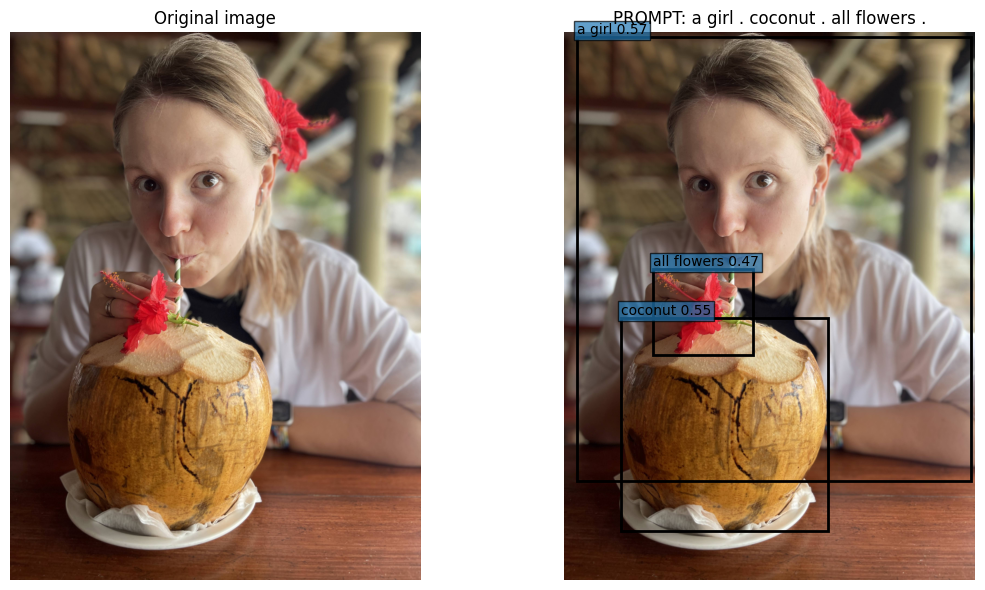

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def annotate(ax, image, boxes, scores, labels):
    """
    Рисует bounding boxes и labels на существующей оси matplotlib.
    """

    ax.imshow(image)

    for box, score, label in zip(boxes, scores, labels):
        x1, y1, x2, y2 = box.cpu().numpy()

        # Bounding box
        rect = Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2,
        )

        ax.add_patch(rect)

        # Label
        ax.text(
            x1,
            y1,
            f"{label} {score:.2f}",
            fontsize=10,
            verticalalignment="bottom",
            bbox=dict(
                alpha=0.7,
                pad=2,
            ),
        )

    ax.axis("off")

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Original
ax[0].imshow(image)
ax[0].set_title("Original image")
ax[0].axis("off")

# DINO
annotate(
    ax=ax[1],
    image=image,
    boxes=boxes,
    scores=scores,
    labels=labels,
)

ax[1].set_title(f"PROMPT: {text}")

plt.tight_layout()
plt.show()

### попробуем dino + SAM

In [5]:
# Устанавливаем репозиторий
%pip install git+https://github.com/facebookresearch/segment-anything.git

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-9909tod0
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-9909tod0
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.


In [6]:
# Берём хороший чекпоинт
! wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
HOME = "/kaggle/working/"
! mkdir {HOME}/weights

WEIGHTS_NAME = 'sam_vit_h_4b8939.pth'
! mv {WEIGHTS_NAME} {HOME}/weights/

--2026-08-13 09:25:56--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.171.22.68, 3.171.22.33, 3.171.22.13, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.171.22.68|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2564550879 (2.4G) [binary/octet-stream]
Saving to: ‘sam_vit_h_4b8939.pth’

sam_vit_h_4b8939.pt 100%[===================>]   2.39G   173MB/s    in 13s     

2026-08-13 09:26:10 (182 MB/s) - ‘sam_vit_h_4b8939.pth’ saved [2564550879/2564550879]



In [7]:
# Импортируем нужные методы
from segment_anything import build_sam, SamPredictor 

# Вспомогательная функция для отрисовки масок
def show_mask(mask, image, random_color=True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.8])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    
    annotated_frame_pil = Image.fromarray(image).convert('RGBA')
    mask_image_pil = Image.fromarray((mask_image.cpu().numpy() * 255).astype(np.uint8)).convert('RGBA')

    return np.array(Image.alpha_composite(annotated_frame_pil, mask_image_pil))

# Создаём модель и подгружаем веса
sam_checkpoint = f'{HOME}/weights/sam_vit_h_4b8939.pth'

sam = build_sam(checkpoint=sam_checkpoint)
sam.to(device=DEVICE)
sam_predictor = SamPredictor(sam)

In [8]:
TEXT_PROMPT_SAM = 'coconut . '

inputs = processor(
    images=image,
    text=TEXT_PROMPT_SAM,
    return_tensors="pt",
)

inputs = {
    k: v.to(DEVICE) if hasattr(v, "to") else v
    for k, v in inputs.items()
}

with torch.no_grad():
    outputs = model(**inputs)

results_coconut = processor.post_process_grounded_object_detection(
    outputs,
    inputs["input_ids"],
    threshold=0.35,
    text_threshold=0.25,
    target_sizes=[image.size[::-1]],
)

result = results_coconut[0]

boxes_coconut = result["boxes"]
scores_coconut = result["scores"]
labels_coconut = result["labels"]

In [9]:
image_source = Image.open(IMAGE_PATH).convert("RGB")
image_source = np.asarray(image_source)

# Считаем image embedding для SAM один раз
sam_predictor.set_image(image_source)

In [10]:
# Пересчитываем bbox-ы для SAM
transformed_boxes = sam_predictor.transform.apply_boxes_torch(boxes_coconut, image_source.shape[:2]).to(DEVICE)

# Делаем предикт с промптом-боксами
masks_coconut, _, _ = sam_predictor.predict_torch(
            point_coords = None,
            point_labels = None,
            boxes = transformed_boxes,
            multimask_output = False,
        )

annotated_frame_with_mask = show_mask(masks_coconut[0][0].cpu(), image_source)

/tmp/ipykernel_58/3490350065.py:12: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)


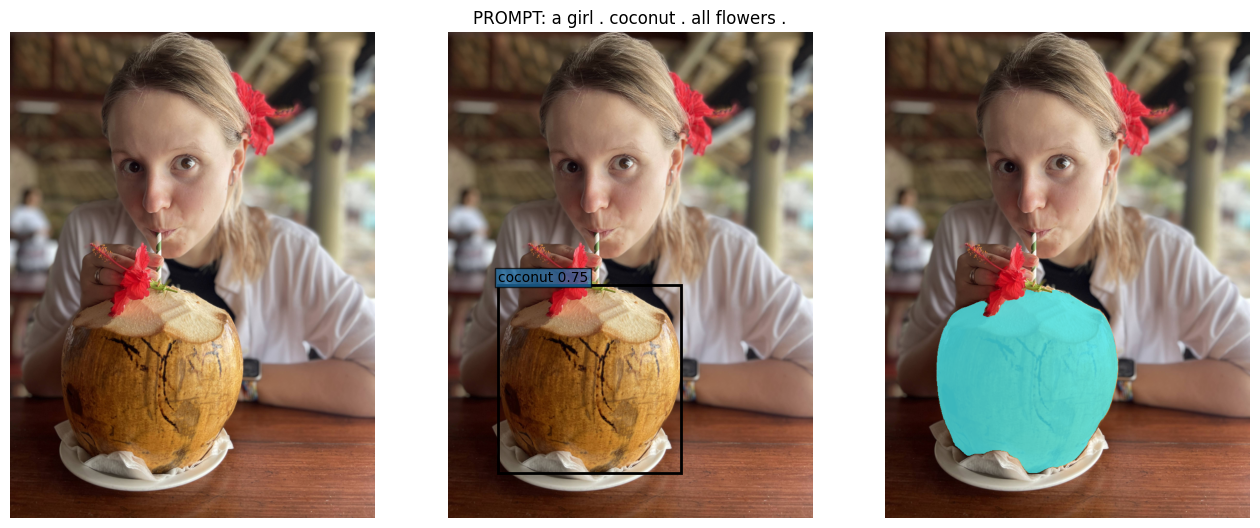

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(16, 12))

ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
ax[0].imshow(image_source)
# show boxes
annotate(
    ax=ax[1],
    image=image_source,
    boxes=boxes_coconut,
    scores=scores_coconut,
    labels=labels_coconut,
)
ax[1].set_title(f"PROMPT: {text}")
ax[2].imshow(annotated_frame_with_mask)

### попробуем воспроизвести маскирование с Толей

In [12]:
IMAGE_PATH = "/kaggle/input/datasets/andreykurdyubov/cv-lesson-10-data/data/Tolya.png"

image_tolya = Image.open(IMAGE_PATH).convert("RGB")
image_tolya = np.asarray(image_tolya)

# Создаём модель и подгружаем веса
sam_checkpoint = f'{HOME}/weights/sam_vit_h_4b8939.pth'

sam = build_sam(checkpoint=sam_checkpoint)
sam.to(device=DEVICE)
sam_predictor = SamPredictor(sam)

sam_predictor.set_image(image_tolya)

In [13]:
TEXT_PROMPT_SAM = 'man . pomegranate . watch .'

inputs = processor(
    images=image_tolya,
    text=TEXT_PROMPT_SAM,
    return_tensors="pt",
)

inputs = {
    k: v.to(DEVICE) if hasattr(v, "to") else v
    for k, v in inputs.items()
}

with torch.no_grad():
    outputs = model(**inputs)

results_tolya = processor.post_process_grounded_object_detection(
    outputs,
    inputs["input_ids"],
    threshold=0.35,
    text_threshold=0.25,
    target_sizes=[image_tolya.shape[:-1]],
)

result = results_tolya[0]

boxes_tolya = result["boxes"]
scores_tolya = result["scores"]
labels_tolya = result["labels"]

/usr/local/lib/python3.12/dist-packages/transformers/image_processing_backends.py:135: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  image = torch.from_numpy(image).contiguous()


In [14]:
# Пересчитываем bbox-ы для SAM
transformed_boxes = sam_predictor.transform.apply_boxes_torch(boxes_tolya, image_tolya.shape[:2]).to(DEVICE)

# Делаем предикт с промптом-боксами
masks_tolya, _, _ = sam_predictor.predict_torch(
            point_coords = None,
            point_labels = None,
            boxes = transformed_boxes,
            multimask_output = False,
        )

annotated_frame_with_mask = show_mask(masks_tolya[0][0].cpu(), image_tolya)

/tmp/ipykernel_58/3490350065.py:12: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)


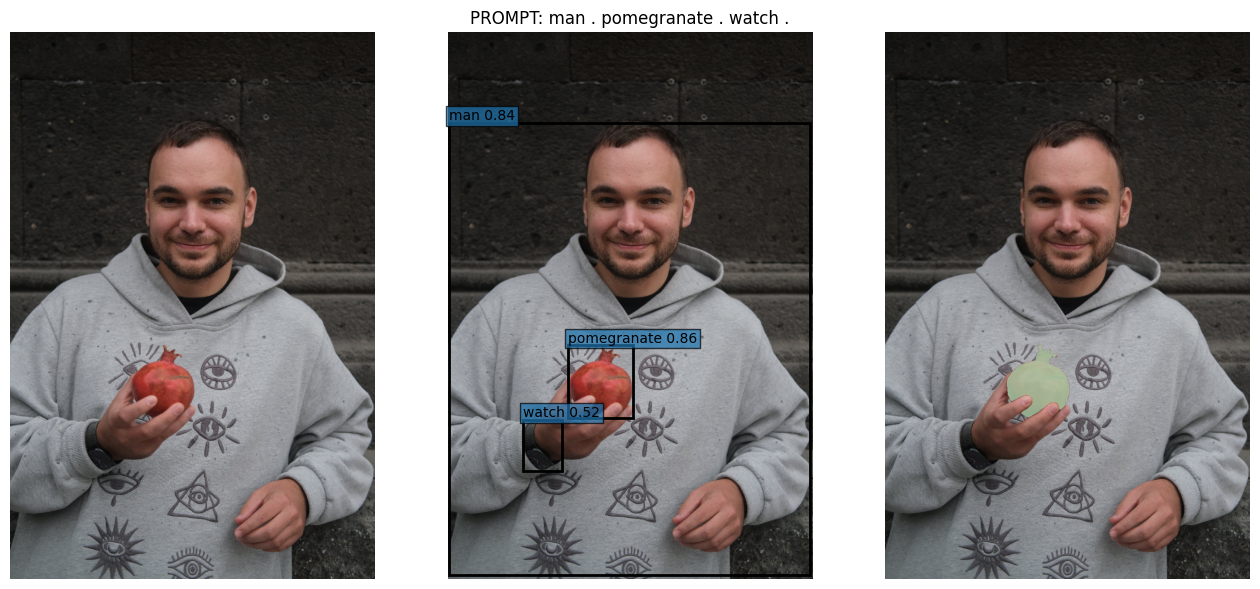

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(16, 12))

ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
ax[0].imshow(image_tolya)
# show boxes
annotate(
    ax=ax[1],
    image=image_tolya,
    boxes=boxes_tolya,
    scores=scores_tolya,
    labels=labels_tolya,
)
ax[1].set_title(f"PROMPT: {TEXT_PROMPT_SAM}")
ax[2].imshow(annotated_frame_with_mask)

### 2026.08.13 теперь попробуем dino + stable diffusion

In [16]:
from diffusers import StableDiffusionInpaintPipeline

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [17]:
if DEVICE == 'cpu':
    float_type = torch.float32
else:
    float_type = torch.float16

pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-inpainting"
)

pipe = pipe.to(DEVICE)

model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

In [18]:
# Смотрим порядок масок в аутпуте
print(labels_tolya)

['pomegranate', 'man', 'watch']


In [19]:
# Нам нужна маска с индексом 1
mask_granate = masks_tolya[0][0].cpu().numpy()

In [20]:
image_source_pil = Image.fromarray(image_tolya)
image_mask_pil = Image.fromarray(mask_granate)

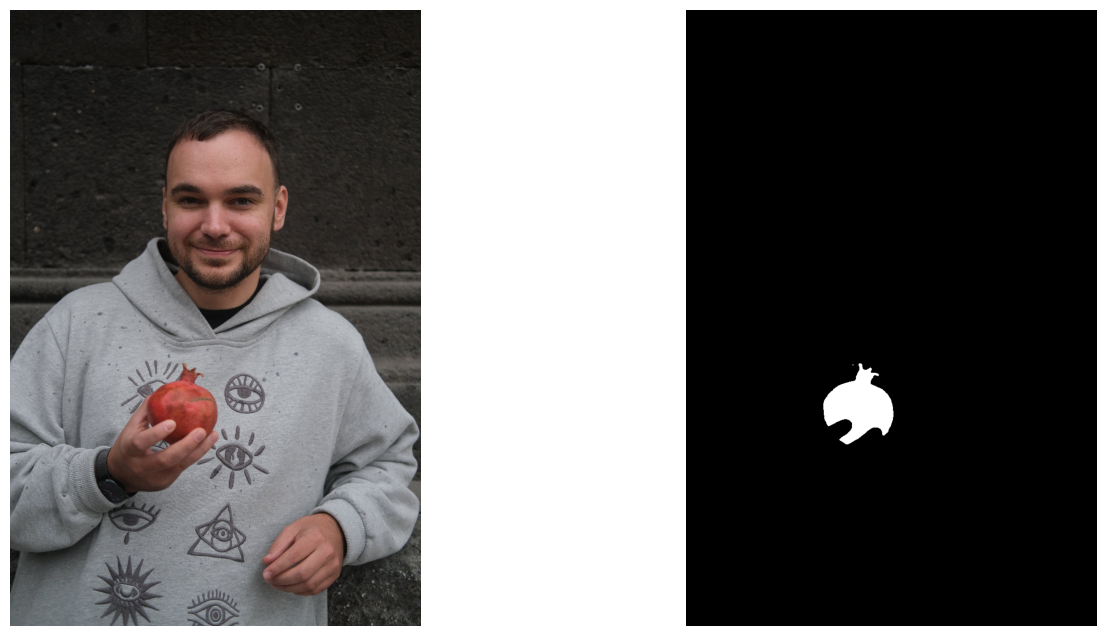

In [21]:
# Убедимся, что маска та, что нужна
fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].axis('off')
ax[1].axis('off')
ax[0].imshow(image_source_pil)
ax[1].imshow(image_mask_pil)

Отлично!

Теперь маску граната — те пиксели, где в маске белый цвет, мы будем использовать как зону для `inpaint`-а, а всё остальное трогать не будем. 

In [22]:
# Делаем ресайз к нужному размеру обоих PIL Images
image_source_for_inpaint = image_source_pil.resize((512, 512))
image_mask_for_inpaint = image_mask_pil.resize((512, 512))

Давайте попробуем заменить гранат на апельсин!

In [39]:
prompt = "an orange, bright and colorful, without changes in hand"

image_inpainting = pipe(prompt=prompt, image=image_source_for_inpaint, mask_image=image_mask_for_inpaint).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

In [40]:
# Возвращаем к первоначальному размеру
image_inpainting = image_inpainting.resize((image_source_pil.size[0], image_source_pil.size[1]))

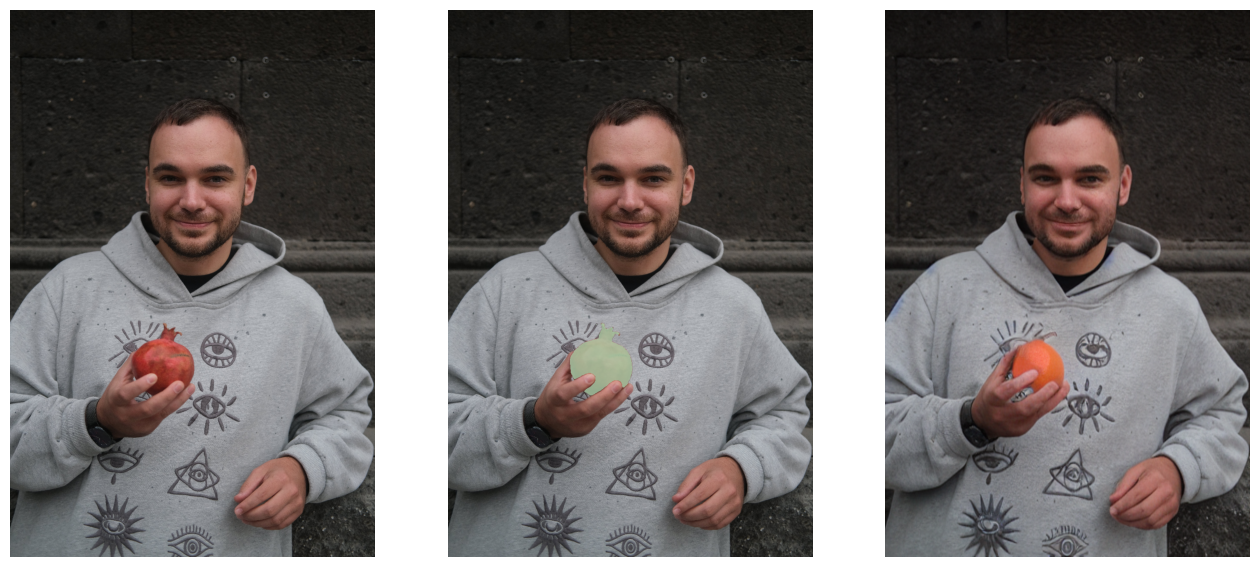

In [41]:
fig, ax = plt.subplots(1, 3, figsize=(16, 8))
ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
ax[0].imshow(image_source_pil)
ax[1].imshow(annotated_frame_with_mask)
ax[2].imshow(image_inpainting)

### еще попытка с другой картинкой

In [42]:
image_source_pil_nastya = Image.fromarray(image_source)
image_mask_pil_nastya = Image.fromarray(masks_coconut[0][0].cpu().numpy())

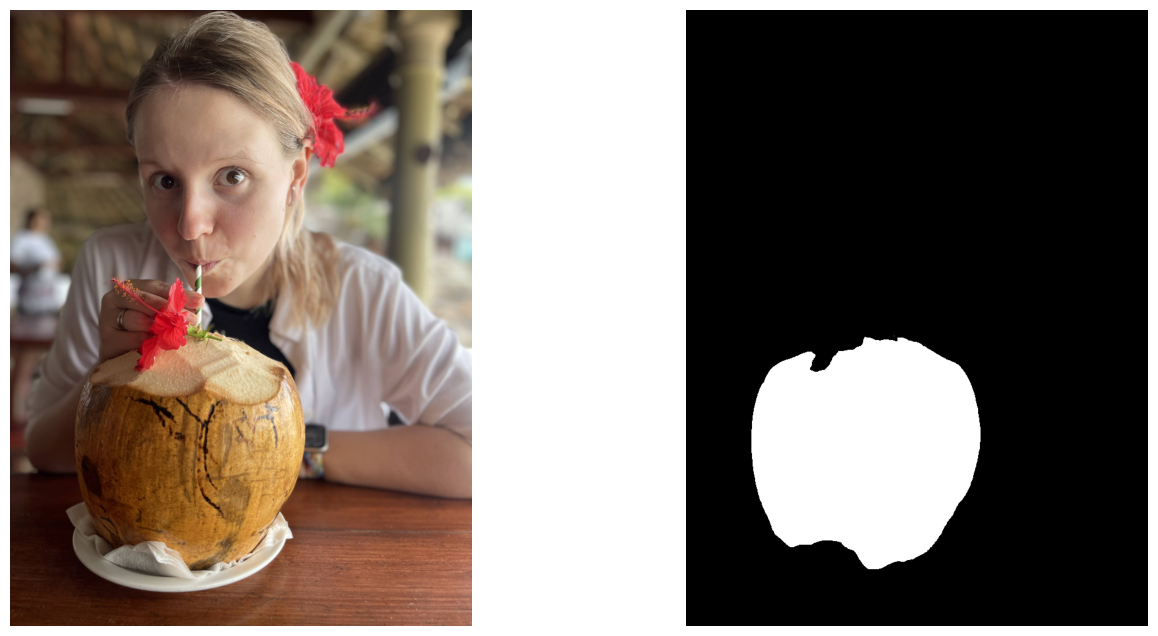

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].axis('off')
ax[1].axis('off')
ax[0].imshow(image_source_pil_nastya)
ax[1].imshow(image_mask_pil_nastya)

In [44]:
image_source_nastya_for_inpaint = image_source_pil_nastya.resize((512, 512))
image_mask_nastya_for_inpaint = image_mask_pil_nastya.resize((512, 512))

In [47]:
prompt = "huge mug full of bright golden beer"

image_inpainting_nastya = pipe(prompt=prompt, image=image_source_nastya_for_inpaint, mask_image=image_mask_nastya_for_inpaint).images[0]
image_inpainting_nastya = image_inpainting_nastya.resize((image_source_pil_nastya.size[0], image_source_pil_nastya.size[1]))

  0%|          | 0/50 [00:00<?, ?it/s]

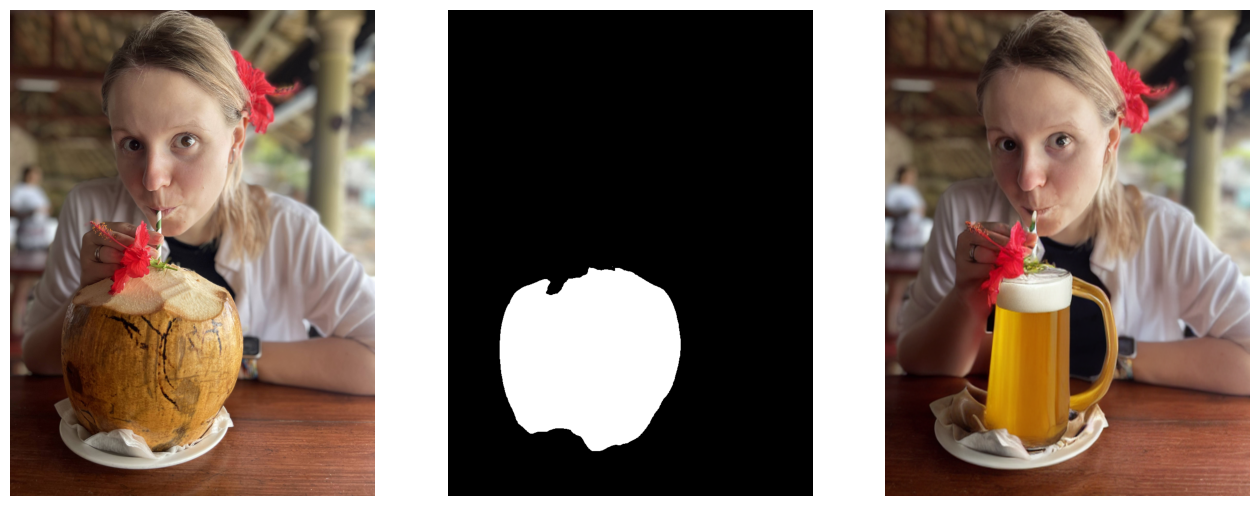

In [48]:
fig, ax = plt.subplots(1, 3, figsize=(16, 8))
ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
ax[0].imshow(image_source_pil_nastya)
ax[1].imshow(image_mask_pil_nastya)
ax[2].imshow(image_inpainting_nastya)